In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import doralite
import gfdl_utils.core as gu
import xarray as xr
import matplotlib.pyplot as plt

In [25]:
odiv_projects = doralite.list_project("odiv")['project']
OM5_experiments = [e for e in odiv_projects if e['title'] == "OM5 experiments"][0]['experiments']

In [26]:
iOM4_dict = doralite.search("iOM4")
master_id = [k for (k,v) in iOM4_dict.items() if "therm" in v][0]
master_id

2520

In [27]:
pp = doralite.dora_metadata(master_id)["pathPP"]
ppname = "ice_shelf"
out = "ts"
local = gu.get_local(pp, ppname, out)
isg = gu.open_static(pp, ppname)
ds_shelf = gu.open_frompp(pp, ppname, out, local, "1982*", "*", dmget=True)

ds_shelf = ds_shelf.assign_coords({
    "geolon": xr.DataArray(isg.GEOLON.values, dims=("yT", "xT")),
    "geolat": xr.DataArray(isg.GEOLAT.values, dims=("yT", "xT"))
})

Issuing dmget command to migrate data to disk. Migration complete.


In [28]:
ppname = "ice"
out = "ts"
local = gu.get_local(pp, ppname, out)
ig = gu.open_static(pp, ppname)
ds_ice = gu.open_frompp(pp, ppname, out, local, "1982*", "*", dmget=True)
ds_ice = ds_ice.assign_coords({
    "geolon": xr.DataArray(ig.GEOLON.values, dims=("yT", "xT")),
    "geolat": xr.DataArray(ig.GEOLAT.values, dims=("yT", "xT"))
})

Issuing dmget command to migrate data to disk. Migration complete.


In [ ]:
pp = doralite.dora_metadata(master_id)["pathPP"]
ppname = "ocn"
out = "ts"
local = gu.get_local(pp, ppname, out)
og = gu.open_static(pp, "ocean_monthly")

ds = gu.open_frompp(pp, ppname, out, local, "1982*", "*", dmget=True)
ds = ds.assign_coords({
    "geolon": xr.DataArray(og.geolon.values, dims=("yh", "xh")),
    "geolat": xr.DataArray(og.geolat.values, dims=("yh", "xh")),
})

In [30]:
ds_shelf = xr.merge([ds.drop_dims(["xh", "yh", "xq", "yq"]), ds_shelf])
ds = ds.drop_dims(["xT", "yT"])

In [31]:
import xgcm

In [32]:
coords = {
    "X": {"center": "xT", "right": "xB"},
    "Y": {"center": "yT", "right": "yB"}
}
grid = xgcm.Grid(
    ds_shelf,
    coords=coords,
    boundary={"X":"periodic", "Y":"extend"},
    metrics={},
    autoparse_metadata=False,
)

In [33]:
import numpy as np
grid._ds["speed"] = grid.interp(
    grid.interp(
        np.sqrt(
            ds_shelf.u_shelf**2 + 
            ds_shelf.v_shelf**2
        ),
        axis="X"
    ), axis="Y"
)

/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xgcm/grid_ufunc.py:836: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/work/hfd/.conda/envs/CM4X/lib/python3.12/site-packages/xgcm/grid_ufunc.py:836: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


In [34]:
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cmocean.cm as cm
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [35]:
def polar_plot(da, **kwargs):
    fig = plt.figure(figsize=(7,5.5))
    ax = plt.subplot(1,1,1, facecolor="lightgray", projection=ccrs.SouthPolarStereo())
    cb = ax.pcolormesh(
        da.geolon, da.geolat, da,
        transform=ccrs.PlateCarree(),
        **{k:v for (k,v) in kwargs.items() if k!="label"}
    )
    plt.colorbar(cb, ax=ax, **{k:v for (k,v) in kwargs.items() if k=="label"})
    
    # Limit the map to -60 degrees latitude and below.
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    
    # Compute a circle in axes coordinates, which we can use as a boundary
    # for the map. We can pan/zoom as much as we like - the boundary will be
    # permanently circular.
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)

    ax.set_boundary(circle, transform=ax.transAxes)
    return fig, ax

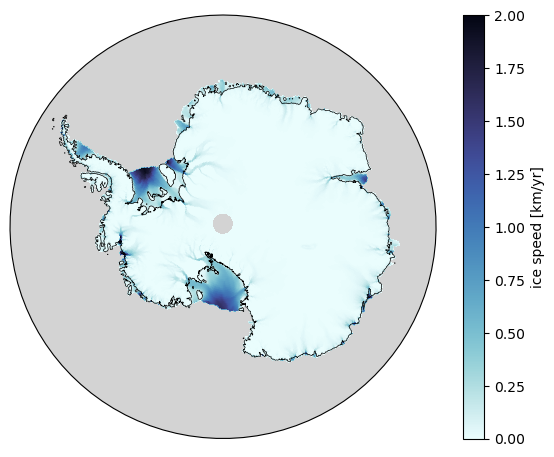

In [36]:
speed_in_km_per_year = 1e-3*grid._ds.speed.isel(time=slice(-12, None)).mean("time")
fig, ax = polar_plot(
    speed_in_km_per_year.where(speed_in_km_per_year),
    label="ice speed [km/yr]", vmin=0, vmax=2, cmap=cm.ice_r
)

grounding_mask = grid._ds.ice_ground_frac.isel(time=0)
grounding_mask.plot.contour(
    x="geolon", y="geolat", colors="k", levels=[0.5],
    ax=ax, transform=ccrs.PlateCarree(),
    linewidths=0.5
)
ax.set_title("")
ax.plot([],[],label="Grounding Line");

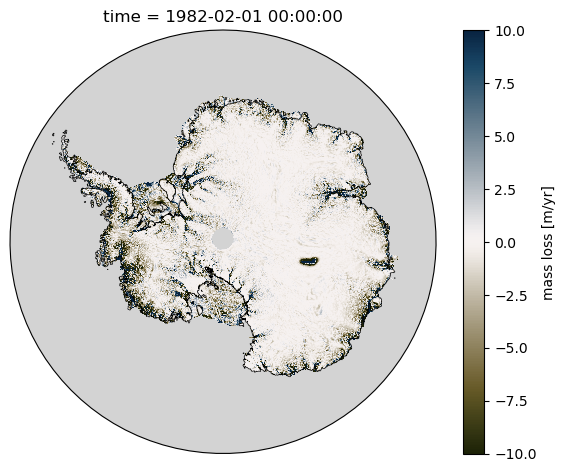

In [39]:
mass_loss = (
    grid._ds["h_shelf"].isel(time=slice(-12, None)).mean("time") -
    grid._ds["h_shelf"].isel(time=slice(0, 12)).mean("time")
)

rho_i = 917.
grid._ds['V_shelf'] = grid._ds.h_shelf*ds_shelf.area_shelf_h
antarctic_mass_loss = ((
    grid._ds.V_shelf.isel(time=slice(-12, None)).mean("time") -
    grid._ds.V_shelf.isel(time=slice(0, 12)).mean("time")
).sum(["xT", "yT"]).values * rho_i)

fig, ax = polar_plot(
    mass_loss.where(mass_loss),
    label="mass loss [m/yr]", vmin=-10, vmax=10, cmap=cm.diff_r
)

grounding_mask = grid._ds.ice_ground_frac.isel(time=0)
grounding_mask.plot.contour(
    x="geolon", y="geolat", colors="k", levels=[0.5],
    ax=ax, transform=ccrs.PlateCarree(),
    linewidths=0.5
)
#ax.set_title(f"Integrated mass loss: {np.rint(antarctic_mass_loss*1e-12)} Gt/year")
ax.plot([],[],label="Grounding Line");

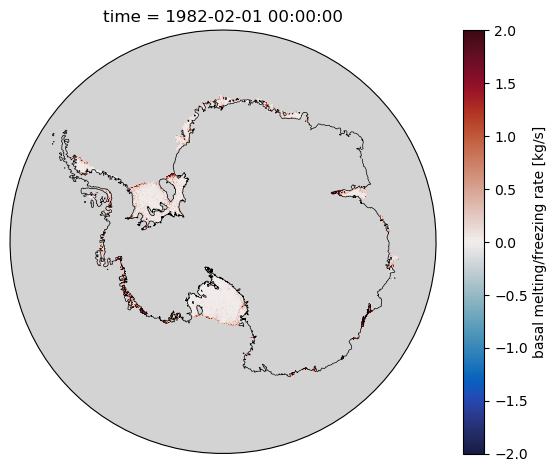

In [40]:
melt_rate = grid._ds.melt.isel(time=slice(-12,None)).mean("time")

fig, ax = polar_plot(
    melt_rate.where(melt_rate),
    label="basal melting/freezing rate [kg/s]", vmin=-2, vmax=2, cmap=cm.balance
)

rho_i = 917.
antarctic_melt_rate = (
    (ds_shelf.melt * ds_shelf.area_shelf_h)
    .isel(time=slice(-12,None)).mean("time")
    .sum(["xT", "yT"]).values * rho_i
)

grounding_mask = grid._ds.ice_ground_frac.isel(time=0)
grounding_mask.plot.contour(
    x="geolon", y="geolat", colors="k", levels=[0.5],
    ax=ax, transform=ccrs.PlateCarree(),
    linewidths=0.5
)
#ax.set_title(f"Integrated melt rate: {np.rint(antarctic_melt_rate*1e-12)} Gt/year")
ax.plot([],[],label="Grounding Line");